<a href="https://colab.research.google.com/github/aryancodes12/Advance-Machine-Learning/blob/main/gearbox_failure.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

filepath = "/content/drive/MyDrive/CDPL SEM 3/dataset/gearbox failure dataset.csv"

data = pd.read_csv(filepath)

df = pd.DataFrame(data)

In [2]:
df.head()

,Load_%,Temperature_C,Vibration_mm_s,Oil_Level_%,Failure
0,1.170199,-1.610199,1.290988,-1.410081,0
1,0.198680,1.999221,0.504205,1.488123,1
2,1.695723,0.626734,0.569711,-0.277651,1
3,-0.531455,-0.669270,-1.600362,-2.724787,0
4,0.194052,-2.979343,-0.202986,1.018522,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Load_%          1000 non-null   float64
 1   Temperature_C   1000 non-null   float64
 2   Vibration_mm_s  1000 non-null   float64
 3   Oil_Level_%     1000 non-null   float64
 4   Failure         1000 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 39.2 KB


In [5]:
df.shape

(1000, 5)

In [7]:
df.columns

Index(['Load_%', 'Temperature_C', 'Vibration_mm_s', 'Oil_Level_%', 'Failure'], dtype='object')

In [8]:
df.isnull().sum()

,0
Load_%,0
Temperature_C,0
Vibration_mm_s,0
Oil_Level_%,0
Failure,0


In [9]:
df['Failure'].value_counts()

,count
Failure,
0,501
1,499


In [10]:
df.describe()

,Load_%,Temperature_C,Vibration_mm_s,Oil_Level_%,Failure
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.019106,0.009486,0.732060,-0.751864,0.499000
std,1.025963,1.620364,1.595817,1.571900,0.500249
min,-2.929449,-4.450596,-4.278978,-4.337231,0.000000
25%,-0.742637,-1.453959,-0.181916,-1.808776,0.000000
50%,-0.004724,0.233930,1.053498,-1.202489,0.000000
75%,0.673381,1.445834,1.866559,0.224259,1.000000
max,3.243093,3.360860,4.341188,5.119524,1.000000


# Visualization

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

## Histogram

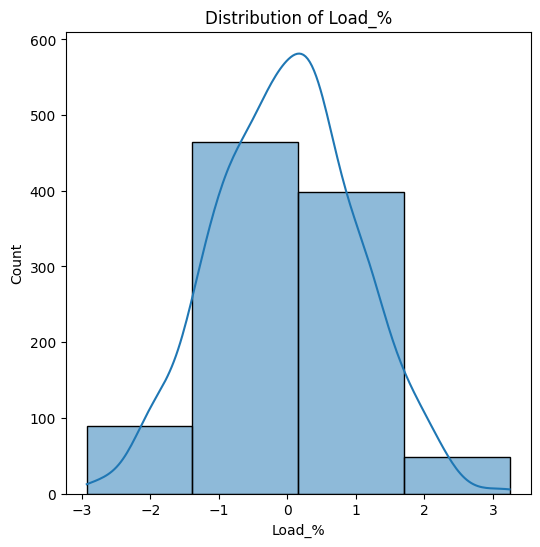

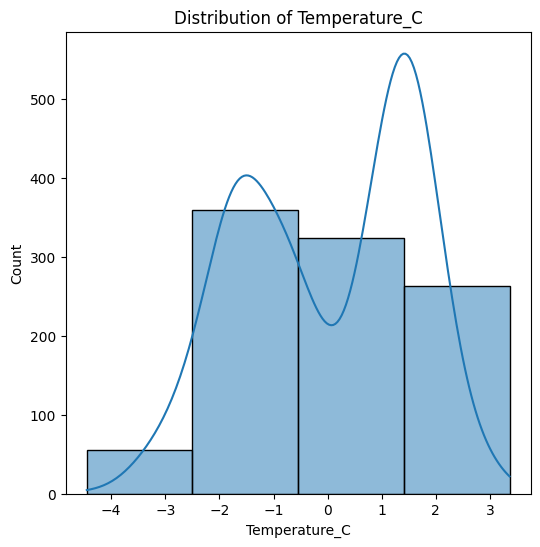

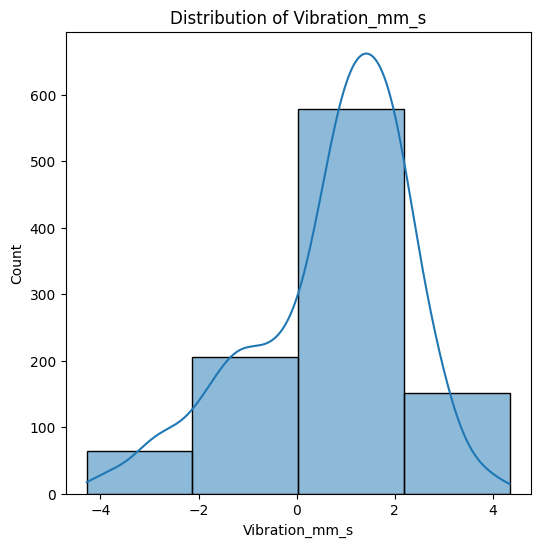

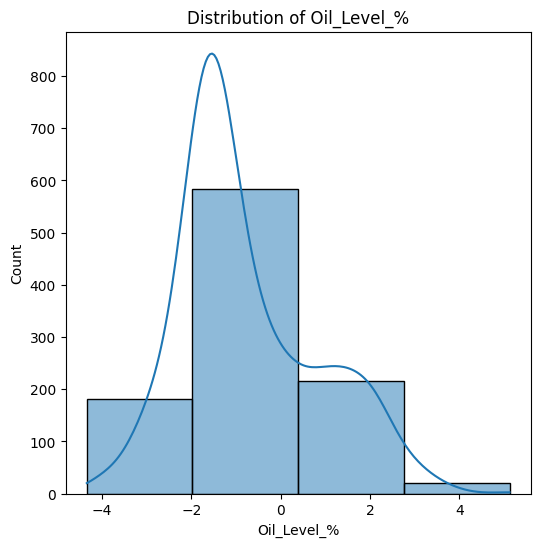

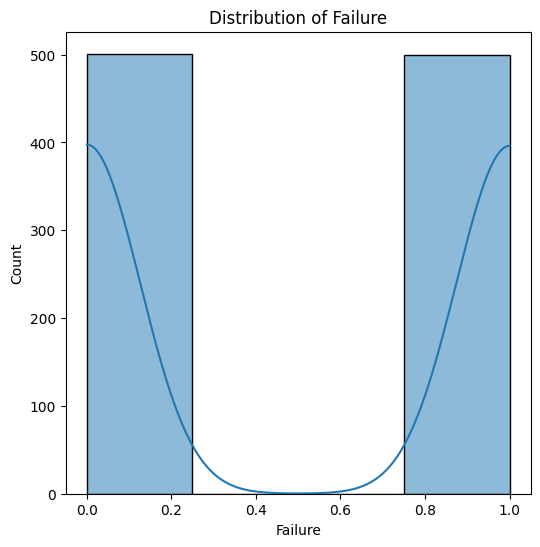

In [14]:
for col in df.columns:
  plt.figure(figsize = (6, 6))
  sns.histplot(df[col], kde = True, bins = 4)
  plt.title(f"Distribution of {col}")
  plt.show()
  print("\n\n\n")

## BOXPLOT

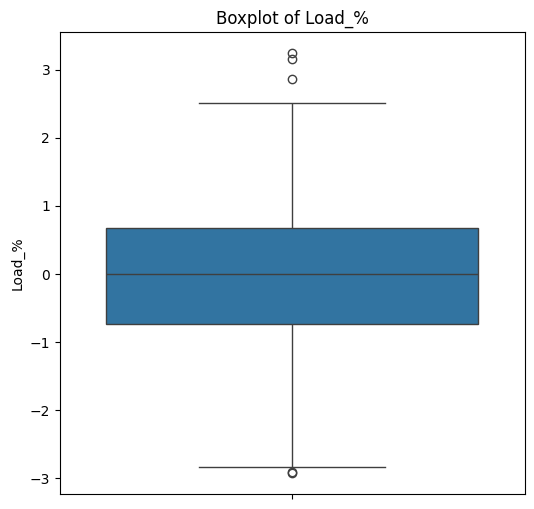

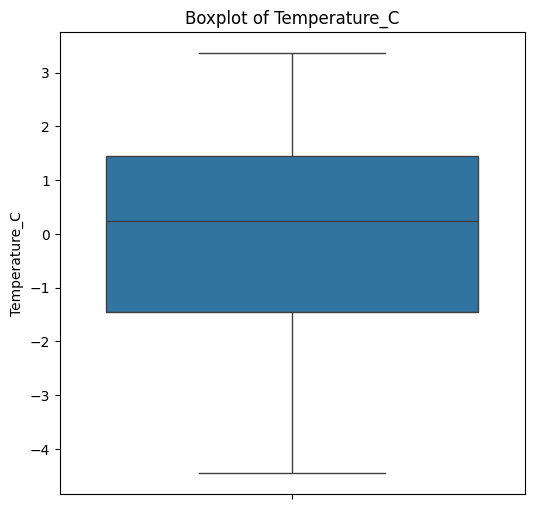

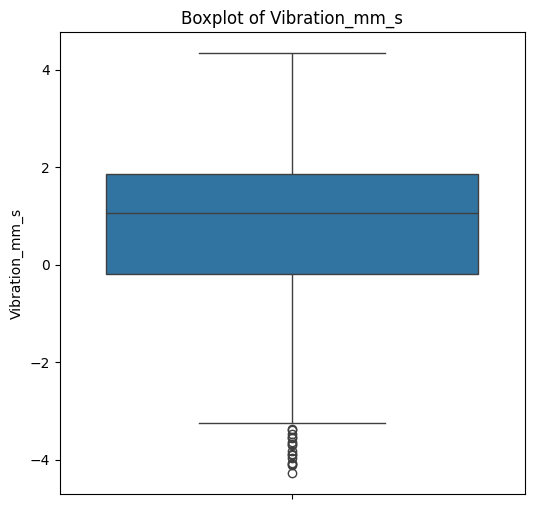

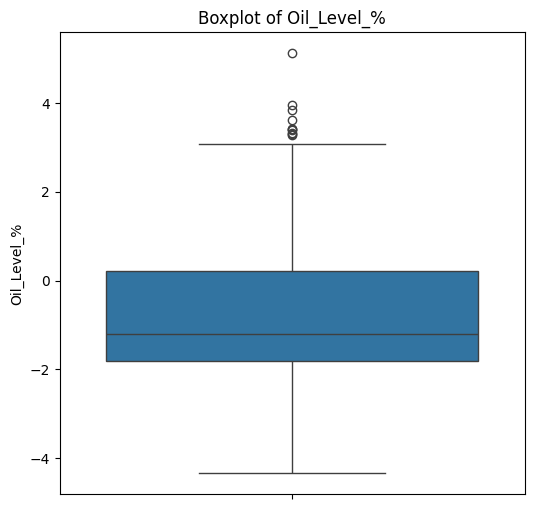

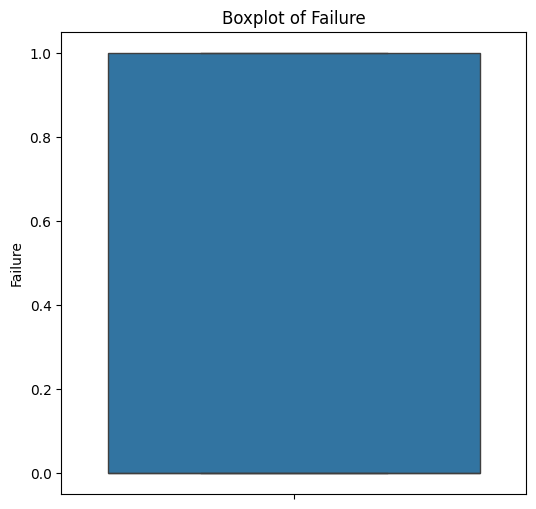

In [15]:
for col in df.columns:
  plt.figure(figsize = (6, 6))
  sns.boxplot(df[col])
  plt.title(f"Boxplot of {col}")
  plt.show()
  print("\n\n\n")

## Scatter plot

In [16]:
#Checking for correlation
df.corr()

,Load_%,Temperature_C,Vibration_mm_s,Oil_Level_%,Failure
Load_%,1.000000,-0.020930,-0.046029,-0.030906,-0.022156
Temperature_C,-0.020930,1.000000,0.457499,0.406325,0.880535
Vibration_mm_s,-0.046029,0.457499,1.000000,0.126093,0.416736
Oil_Level_%,-0.030906,0.406325,0.126093,1.000000,0.484635
Failure,-0.022156,0.880535,0.416736,0.484635,1.000000


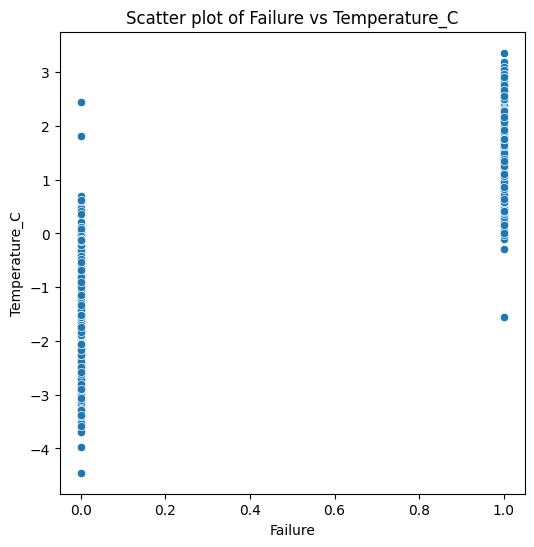

In [21]:

plt.figure(figsize = (6, 6))
sns.scatterplot(data = df, x = "Failure", y = "Temperature_C")
plt.title(f"Scatter plot of Failure vs Temperature_C")
plt.show()
print("\n\n\n")

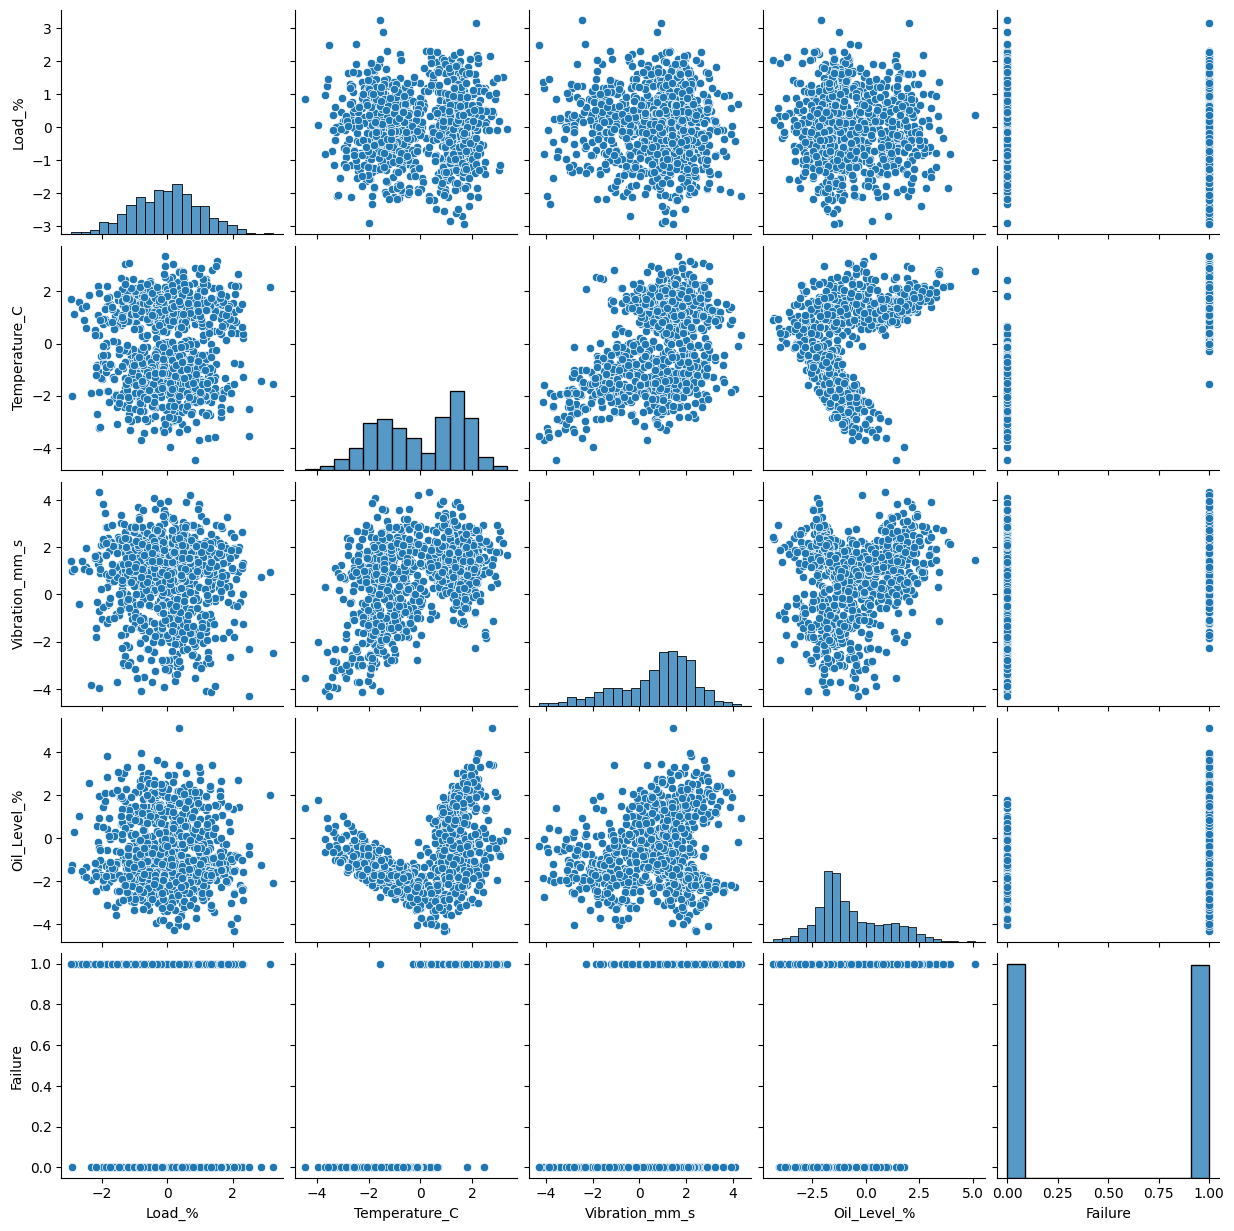

In [22]:
# Multivariate analysis
sns.pairplot(df)

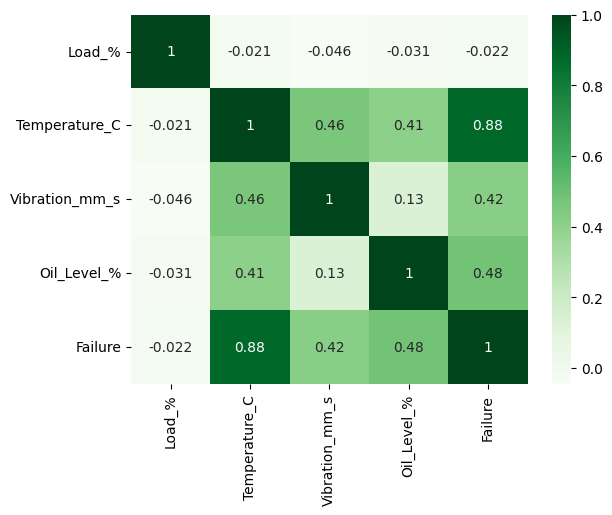

In [27]:
sns.heatmap(df.corr(), annot = True, cmap = "Greens")
plt.show()

## Splitting the data

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Load_%          1000 non-null   float64
 1   Temperature_C   1000 non-null   float64
 2   Vibration_mm_s  1000 non-null   float64
 3   Oil_Level_%     1000 non-null   float64
 4   Failure         1000 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 39.2 KB


In [31]:
X = df.drop("Failure", axis = 1)
y = df['Failure']

In [32]:
# Train and Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state = 42)

## Model Selection

In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

#predict
y_pred_dt = dt.predict(X_test)

#accuracy
print(accuracy_score(y_test,y_pred_dt))

0.97


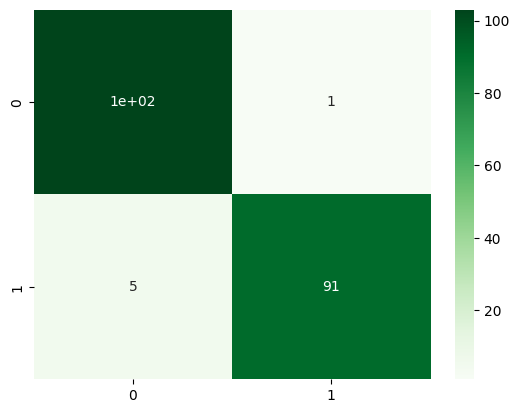

In [40]:
acc_dt = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(acc_dt, annot = True, cmap = "Greens")
plt.show()

In [39]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print(accuracy_score(y_test, y_pred_rf))

0.98


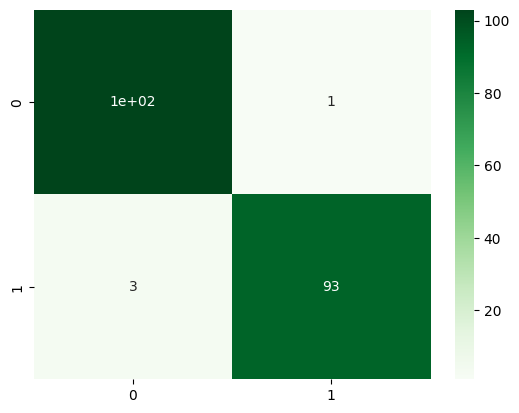

In [42]:
acc_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(acc_rf, annot = True, cmap = "Greens")
plt.show()

In [43]:
#XGBoost

from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print(accuracy_score(y_test, y_pred_xgb))

0.98


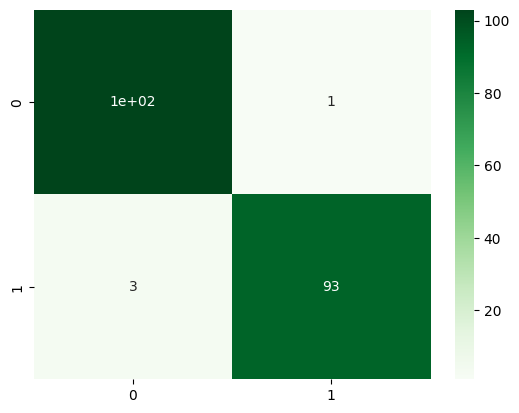

In [44]:
acc_xgb = confusion_matrix(y_test, y_pred_xgb)

sns.heatmap(acc_xgb, annot = True, cmap = "Greens")
plt.show()

In [45]:
#Distance based model
#kmeans

from sklearn.cluster import KMeans
km = KMeans()

km.fit(X_train, y_train)

y_pred_km = km.predict(X_test)

print(accuracy_score(y_test, y_pred_km))

0.0


<Axes: >

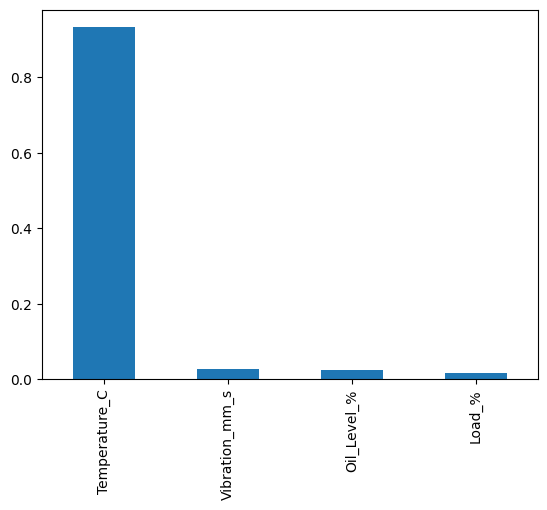

In [46]:
#Feature imp of XGBoost

feature_imp = pd.Series(xgb.feature_importances_, index = X.columns).sort_values(ascending = False)
feature_imp.plot(kind = "bar")


## Model downloading

In [47]:
import joblib

joblib.dump(xgb, "gearbox_failure_predictor.pkl")

['gearbox_failure_predictor.pkl']

In [48]:
from google.colab import files

files.download("gearbox_failure_predictor.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>